In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [4]:
# Load dataset
df = pd.read_csv("C:/Users/Joysmita/OneDrive/Desktop/GOOGLE FORM ML (Responses).csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
df.head()

Dataset loaded successfully!
Shape of dataset: (77, 18)


,Timestamp,Age Group,Gender,Which social media platforms do you use?,How many hours do you spend on social media daily? (,What is your primary purpose of using social media?,How do you generally feel after using social media?,What is the level of Anxiety after usage?,Do you compare yourself with others?,Do you feel sleep disturbance due to social media?,What type of content do you prefer to watch the most on social media?,How likely are you to believe information shared on social media?,What is your usual activity on social media?,How do you react to negative comments or posts online?,How often do you feel social media influences your opinions or decisions?,How often do you feel addicted to social media?,Email Address,Name
0,3-22-2026 4:14:38,1824,Male,"Instagram, Snapchat",13 hours,Education,Neutral,Moderate,Sometimes,Sometimes,Educational content,Neutral,Chatting/Messaging,Ignore them,Rarely,Sometimes,NaN,NaN
1,3-22-2026 4:24:15,1824,Male,Facebook,13 hours,Education,Neutral,Moderate,Sometimes,Sometimes,Influencer content,Neutral,Posting content,Feel slightly affected,Often,Often,NaN,NaN
2,3-22-2026 4:25:39,1824,Male,Facebook,35 hours,Education,Neutral,Moderate,Sometimes,Sometimes,Influencer content,Likely,Chatting/Messaging,Feel upset,Sometimes,Often,NaN,NaN
3,3-22-2026 4:51:47,1824,Female,Instagram,35 hours,Entertainment,Neutral,Very Low,Rarely,Never,Memes,Unlikely,Scrolling/Watching content,Ignore them,Rarely,Sometimes,babitadebnath601@gmail.com,Babita Debnath
4,3-22-2026 4:58:23,1824,Female,Instagram,13 hours,Entertainment,Positive,Very Low,Rarely,Never,News,Very Unlikely,Commenting/Engaging,Respond or argue,Very Often,Rarely,joysmita312@gmail.com,Joysmita


In [5]:
def clean_text(x):
    if pd.isna(x):
        return x
    x = str(x)
    x = x.replace('\x96', '-').replace('', '-').replace('\xa0', ' ')
    x = ' '.join(x.split())
    return x.strip()

# Clean column names
df.columns = [clean_text(col) for col in df.columns]

# Clean all string values
for col in df.columns:
    df[col] = df[col].apply(clean_text)

print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['Timestamp', 'Age Group', 'Gender', 'Which social media platforms do you use?', 'How many hours do you spend on social media daily? (', 'What is your primary purpose of using social media?', 'How do you generally feel after using social media?', 'What is the level of Anxiety after usage?', 'Do you compare yourself with others?', 'Do you feel sleep disturbance due to social media?', 'What type of content do you prefer to watch the most on social media?', 'How likely are you to believe information shared on social media?', 'What is your usual activity on social media?', 'How do you react to negative comments or posts online?', 'How often do you feel social media influences your opinions or decisions?', 'How often do you feel addicted to social media?', 'Email Address', 'Name']


In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
for col in df.columns:
    print("-", col)

Number of Rows: 77
Number of Columns: 18

Column Names:
- Timestamp
- Age Group
- Gender
- Which social media platforms do you use?
- How many hours do you spend on social media daily? (
- What is your primary purpose of using social media?
- How do you generally feel after using social media?
- What is the level of Anxiety after usage?
- Do you compare yourself with others?
- Do you feel sleep disturbance due to social media?
- What type of content do you prefer to watch the most on social media?
- How likely are you to believe information shared on social media?
- What is your usual activity on social media?
- How do you react to negative comments or posts online?
- How often do you feel social media influences your opinions or decisions?
- How often do you feel addicted to social media?
- Email Address
- Name


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 18 columns):
 #   Column                                                                     Non-Null Count  Dtype 
---  ------                                                                     --------------  ----- 
 0   Timestamp                                                                  77 non-null     object
 1   Age Group                                                                  77 non-null     object
 2   Gender                                                                     77 non-null     object
 3   Which social media platforms do you use?                                   77 non-null     object
 4   How many hours do you spend on social media daily? (                       77 non-null     object
 5   What is your primary purpose of using social media?                        77 non-null     object
 6   How do you generally feel after using social media?                 

In [9]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Timestamp                                                                    0
Age Group                                                                    0
Gender                                                                       0
Which social media platforms do you use?                                     0
How many hours do you spend on social media daily? (                         0
What is your primary purpose of using social media?                          0
How do you generally feel after using social media?                          0
What is the level of Anxiety after usage?                                    0
Do you compare yourself with others?                                         0
Do you feel sleep disturbance due to social media?                           0
What type of content do you prefer to watch the most on social media?        3
How likely are you to believe information shared on social media?            0
What is your usual activity on soci

In [10]:
# Keep a copy
data = df.copy()

# Drop personal identity columns
data.drop(columns=["Email Address", "Name"], inplace=True, errors="ignore")

print("Columns after dropping unnecessary identity columns:")
print(data.columns.tolist())

Columns after dropping unnecessary identity columns:
['Timestamp', 'Age Group', 'Gender', 'Which social media platforms do you use?', 'How many hours do you spend on social media daily? (', 'What is your primary purpose of using social media?', 'How do you generally feel after using social media?', 'What is the level of Anxiety after usage?', 'Do you compare yourself with others?', 'Do you feel sleep disturbance due to social media?', 'What type of content do you prefer to watch the most on social media?', 'How likely are you to believe information shared on social media?', 'What is your usual activity on social media?', 'How do you react to negative comments or posts online?', 'How often do you feel social media influences your opinions or decisions?', 'How often do you feel addicted to social media?']


In [11]:
# Convert timestamp to datetime
data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors="coerce")

# Feature engineering from timestamp
data["Hour"] = data["Timestamp"].dt.hour
data["Day"] = data["Timestamp"].dt.day
data["Month"] = data["Timestamp"].dt.month

# Drop original timestamp after extracting useful info
data.drop(columns=["Timestamp"], inplace=True)

print("Timestamp converted into Hour, Day, Month.")
data.head()

Timestamp converted into Hour, Day, Month.


,Age Group,Gender,Which social media platforms do you use?,How many hours do you spend on social media daily? (,What is your primary purpose of using social media?,How do you generally feel after using social media?,What is the level of Anxiety after usage?,Do you compare yourself with others?,Do you feel sleep disturbance due to social media?,What type of content do you prefer to watch the most on social media?,How likely are you to believe information shared on social media?,What is your usual activity on social media?,How do you react to negative comments or posts online?,How often do you feel social media influences your opinions or decisions?,How often do you feel addicted to social media?,Hour,Day,Month
0,18-24,Male,"Instagram, Snapchat",1-3 hours,Education,Neutral,Moderate,Sometimes,Sometimes,Educational content,Neutral,Chatting/Messaging,Ignore them,Rarely,Sometimes,4,22,3
1,18-24,Male,Facebook,1-3 hours,Education,Neutral,Moderate,Sometimes,Sometimes,Influencer content,Neutral,Posting content,Feel slightly affected,Often,Often,4,22,3
2,18-24,Male,Facebook,3-5 hours,Education,Neutral,Moderate,Sometimes,Sometimes,Influencer content,Likely,Chatting/Messaging,Feel upset,Sometimes,Often,4,22,3
3,18-24,Female,Instagram,3-5 hours,Entertainment,Neutral,Very Low,Rarely,Never,Memes,Unlikely,Scrolling/Watching content,Ignore them,Rarely,Sometimes,4,22,3
4,18-24,Female,Instagram,1-3 hours,Entertainment,Positive,Very Low,Rarely,Never,News,Very Unlikely,Commenting/Engaging,Respond or argue,Very Often,Rarely,4,22,3


In [12]:
# Fill missing values in content preference column
if "What type of content do you prefer to watch the most on social media?" in data.columns:
    mode_value = data["What type of content do you prefer to watch the most on social media?"].mode()[0]
    data["What type of content do you prefer to watch the most on social media?"] = \
        data["What type of content do you prefer to watch the most on social media?"].fillna(mode_value)

print("Missing values handled.")
print(data.isnull().sum())

Missing values handled.
Age Group                                                                    0
Gender                                                                       0
Which social media platforms do you use?                                     0
How many hours do you spend on social media daily? (                         0
What is your primary purpose of using social media?                          0
How do you generally feel after using social media?                          0
What is the level of Anxiety after usage?                                    0
Do you compare yourself with others?                                         0
Do you feel sleep disturbance due to social media?                           0
What type of content do you prefer to watch the most on social media?        0
How likely are you to believe information shared on social media?            0
What is your usual activity on social media?                                 0
How do you react to negative

In [13]:
import pandas as pd
import numpy as np

# copy dataset
data = df.copy()

# clean column names
data.columns = data.columns.str.strip()

# remove useless columns
data.drop(columns=["Email Address", "Name"], inplace=True, errors="ignore")

# fix weird dash characters in whole dataset
for col in data.columns:
    data[col] = data[col].astype(str).str.replace("\x96", "-", regex=False).str.strip()

# handle timestamp
data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors="coerce")

# create time-based features
data["Response_Hour"] = data["Timestamp"].dt.hour
data["Response_Day"] = data["Timestamp"].dt.day
data["Response_Month"] = data["Timestamp"].dt.month
data["Response_Weekday"] = data["Timestamp"].dt.dayofweek

# count number of social media platforms used
platform_col = "Which social media platforms do you use?"
data["Num_Platforms"] = data[platform_col].apply(
    lambda x: len([i.strip() for i in str(x).split(",") if i.strip() != ""])
)

# target column
target_col = "How often do you feel addicted to social media?"

# binary target for higher accuracy
data["Addiction_Risk"] = data[target_col].apply(
    lambda x: 1 if x in ["Often", "Very Often"] else 0
)

print("Feature Creation Done")
data.head()

Feature Creation Done


,Timestamp,Age Group,Gender,Which social media platforms do you use?,How many hours do you spend on social media daily? (,What is your primary purpose of using social media?,How do you generally feel after using social media?,What is the level of Anxiety after usage?,Do you compare yourself with others?,Do you feel sleep disturbance due to social media?,...,What is your usual activity on social media?,How do you react to negative comments or posts online?,How often do you feel social media influences your opinions or decisions?,How often do you feel addicted to social media?,Response_Hour,Response_Day,Response_Month,Response_Weekday,Num_Platforms,Addiction_Risk
0,2026-03-22 04:14:38,18-24,Male,"Instagram, Snapchat",1-3 hours,Education,Neutral,Moderate,Sometimes,Sometimes,...,Chatting/Messaging,Ignore them,Rarely,Sometimes,4,22,3,6,2,0
1,2026-03-22 04:24:15,18-24,Male,Facebook,1-3 hours,Education,Neutral,Moderate,Sometimes,Sometimes,...,Posting content,Feel slightly affected,Often,Often,4,22,3,6,1,1
2,2026-03-22 04:25:39,18-24,Male,Facebook,3-5 hours,Education,Neutral,Moderate,Sometimes,Sometimes,...,Chatting/Messaging,Feel upset,Sometimes,Often,4,22,3,6,1,1
3,2026-03-22 04:51:47,18-24,Female,Instagram,3-5 hours,Entertainment,Neutral,Very Low,Rarely,Never,...,Scrolling/Watching content,Ignore them,Rarely,Sometimes,4,22,3,6,1,0
4,2026-03-22 04:58:23,18-24,Female,Instagram,1-3 hours,Entertainment,Positive,Very Low,Rarely,Never,...,Commenting/Engaging,Respond or argue,Very Often,Rarely,4,22,3,6,1,0


In [14]:
# ordinal mappings
age_map = {
    "Below 18": 0,
    "18-24": 1,
    "25-34": 2,
    "35-44": 3
}

usage_map = {
    "Less than 1 hour": 0,
    "1-3 hours": 1,
    "3-5 hours": 2,
    "More than 5 hours": 3
}

feeling_map = {
    "Very Negative": 0,
    "Neutral": 1,
    "Positive": 2,
    "Very Positive": 3
}

level_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Always": 4,
    "Very Often": 4,
    "Very Low": 0,
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very High": 4,
    "Very Unlikely": 0,
    "Unlikely": 1,
    "Neutral": 2,
    "Likely": 3,
    "Very Likely": 4
}

# apply mappings
data["Age_Group_Score"] = data["Age Group"].map(age_map)
data["Usage_Score"] = data["How many hours do you spend on social media daily? ("].map(usage_map)
data["Feeling_Score"] = data["How do you generally feel after using social media?"].map(feeling_map)
data["Anxiety_Score"] = data["What is the level of Anxiety after usage?"].map(level_map)
data["Comparison_Score"] = data["Do you compare yourself with others?"].map(level_map)
data["Sleep_Score"] = data["Do you feel sleep disturbance due to social media?"].map(level_map)
data["Belief_Score"] = data["How likely are you to believe information shared on social media?"].map(level_map)
data["Influence_Score"] = data["How often do you feel social media influences your opinions or decisions?"].map(level_map)

# gender binary
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

print("Feature Transformation Done")
data[[
    "Age_Group_Score", "Usage_Score", "Feeling_Score", "Anxiety_Score",
    "Comparison_Score", "Sleep_Score", "Belief_Score", "Influence_Score"
]].head()

Feature Transformation Done


,Age_Group_Score,Usage_Score,Feeling_Score,Anxiety_Score,Comparison_Score,Sleep_Score,Belief_Score,Influence_Score
0,1,1,1,2,2,2,2,1
1,1,1,1,2,2,2,2,3
2,1,2,1,2,2,2,3,2
3,1,2,1,0,1,0,1,1
4,1,1,2,0,1,0,0,4


In [15]:
# behavioural combined features
data["Mental_Health_Risk"] = data[["Anxiety_Score", "Comparison_Score", "Sleep_Score"]].sum(axis=1)

data["Engagement_Risk"] = data[["Usage_Score", "Influence_Score", "Num_Platforms"]].sum(axis=1)

data["Overall_Risk_Score"] = data[
    ["Usage_Score", "Anxiety_Score", "Comparison_Score", "Sleep_Score", "Influence_Score"]
].sum(axis=1)

# high usage flag
data["High_Usage_Flag"] = data["Usage_Score"].apply(lambda x: 1 if x >= 2 else 0)

# high anxiety flag
data["High_Anxiety_Flag"] = data["Anxiety_Score"].apply(lambda x: 1 if x >= 3 else 0)

# platform dummies
platform_dummies = data[platform_col].str.get_dummies(sep=", ")
platform_dummies.columns = ["Platform_" + col.replace(" ", "_").replace("(", "").replace(")", "") for col in platform_dummies.columns]

# remaining important categorical columns one-hot encode
cat_cols = [
    "What is your primary purpose of using social media?",
    "What type of content do you prefer to watch the most on social media?",
    "What is your usual activity on social media?",
    "How do you react to negative comments or posts online?"
]

cat_dummies = pd.get_dummies(data[cat_cols], drop_first=True)

# merge all extracted features
data_fe = pd.concat([data, platform_dummies, cat_dummies], axis=1)

print("Feature Extraction Done")
print("Shape after extraction:", data_fe.shape)

Feature Extraction Done
Shape after extraction: (77, 58)


In [17]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

drop_cols = [
    "Timestamp",
    "Which social media platforms do you use?",
    "How often do you feel addicted to social media?",
    "Age Group",
    "How many hours do you spend on social media daily? (",
    "How do you generally feel after using social media?",
    "What is the level of Anxiety after usage?",
    "Do you compare yourself with others?",
    "Do you feel sleep disturbance due to social media?",
    "How likely are you to believe information shared on social media? "
]

X = data_fe.drop(columns=[col for col in drop_cols if col in data_fe.columns] + ["Addiction_Risk"], errors="ignore").copy()
y = data_fe["Addiction_Risk"].copy()

# encode all categorical columns
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    elif X[col].dtype == "bool":
        X[col] = X[col].astype(int)

# fill missing values
X = X.fillna(0)

# encode target if categorical
if y.dtype == "object":
    y = LabelEncoder().fit_transform(y.astype(str))

selector = SelectKBest(score_func=mutual_info_classif, k=min(15, X.shape[1]))
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features.tolist())

['What type of content do you prefer to watch the most on social media?', 'How do you react to negative comments or posts online?', 'How often do you feel social media influences your opinions or decisions?', 'Num_Platforms', 'Usage_Score', 'Comparison_Score', 'Influence_Score', 'Mental_Health_Risk', 'Engagement_Risk', 'High_Usage_Flag', 'Platform_YouTube', 'What is your primary purpose of using social media?_Entertainment', 'What is your primary purpose of using social media?_News', 'How do you react to negative comments or posts online?_Feel slightly affected', 'How do you react to negative comments or posts online?_Ignore them']


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print("Feature Scaling Done")
print("Scaled feature shape:", X_scaled.shape)

Feature Scaling Done
Scaled feature shape: (77, 15)


In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# model
rf = RandomForestClassifier(random_state=42)

# tuning
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# prediction
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.625

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.82      0.75        11
           1       0.33      0.20      0.25         5

    accuracy                           0.62        16
   macro avg       0.51      0.51      0.50        16
weighted avg       0.58      0.62      0.59        16


Confusion Matrix:

[[9 2]
 [4 1]]


In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring="accuracy")

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.8125     0.75       0.8        0.6        0.86666667]
Mean CV Accuracy: 0.7658333333333334


In [23]:
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                                              Feature  Importance
8                                     Engagement_Risk    0.135328
7                                  Mental_Health_Risk    0.122859
13  How do you react to negative comments or posts...    0.106470
1   How do you react to negative comments or posts...    0.103266
3                                       Num_Platforms    0.098985
5                                    Comparison_Score    0.074293
2   How often do you feel social media influences ...    0.066316
6                                     Influence_Score    0.061579
4                                         Usage_Score    0.054518
0   What type of content do you prefer to watch th...    0.050003
9                                     High_Usage_Flag    0.038735
14  How do you react to negative comments or posts...    0.029215
11  What is your primary purpose of using social m...    0.026679
10                                   Platform_YouTube    0.018854
12  What i

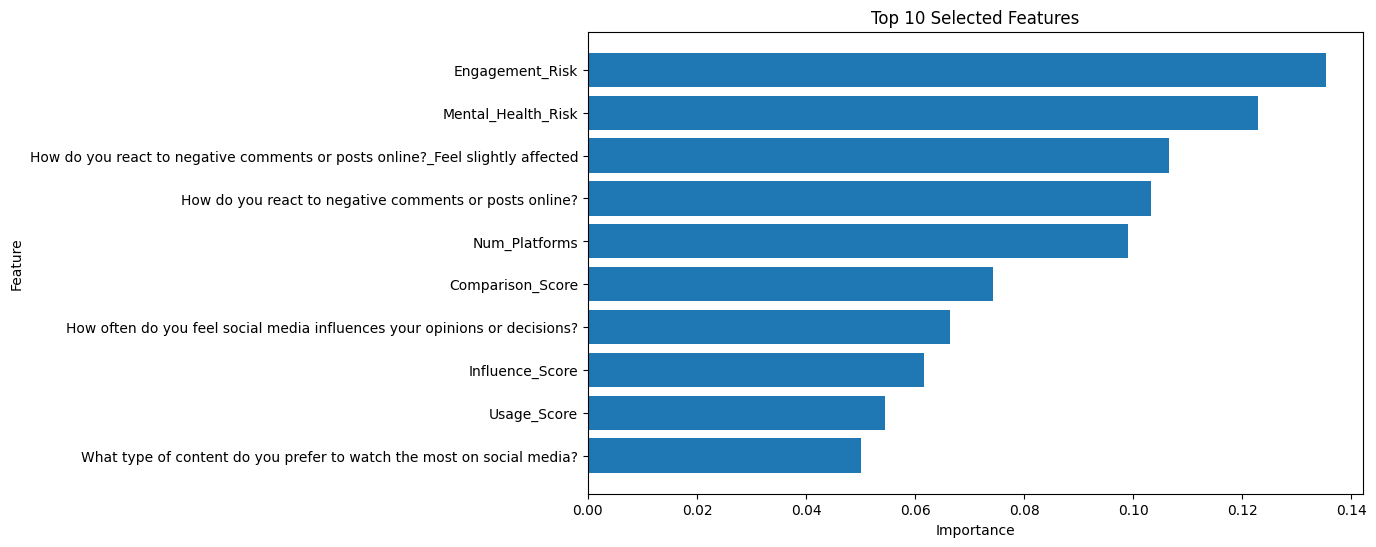

In [24]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Selected Features")
plt.gca().invert_yaxis()
plt.show()